# PDF Exploration & Structure Analysis
## Industrial Equipment Data Extraction Project

This notebook systematically answers the following questions about the source PDFs:

| # | Question |
|---|----------|
| 1 | Are the PDFs text-based or scanned? |
| 2 | How many pages does each have? |
| 3 | What text can we extract? |
| 4 | Are there tables? |
| 5 | How is equipment information organized? |
| 6 | Are the two PDFs structured similarly? |
| 7 | What fields do we need to extract? |

**Source PDFs:**
- `AUSTCOLD.pdf`
- `MYCOM Operating and Maintenance Manual Refrigeration Unit (1).pdf`

**Libraries used:** `pdfplumber`, `pypdfium2`, `pdfminer.six`


## Setup & Imports

In [1]:
import os
import re
import sys
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import pdfplumber
import pypdfium2 as pdfium

warnings.filterwarnings('ignore')


PROJECT_ROOT = Path(os.getcwd()).parent
DATA_DIR     = PROJECT_ROOT / 'data' / 'raw'

PDF_AUSTCOLD = DATA_DIR / 'AUSTCOLD.pdf'
PDF_MYCOM    = DATA_DIR / 'MYCOM Operating and Maintenance Manual Refrigeration Unit (1).pdf'

PDFS = {
    'AUSTCOLD': PDF_AUSTCOLD,
    'MYCOM':    PDF_MYCOM,
}

print('Library versions:')
import pdfplumber as _pp
print(f'  pdfplumber  : {_pp.__version__}')
print()
for name, path in PDFS.items():
    size_mb = path.stat().st_size / 1_048_576
    if path.exists():  
        print(f'{name}: {path.name}  ({size_mb:.1f} MB)')
    else:
        print(f'{name}: {path.name}  (file not found)')

Library versions:
  pdfplumber  : 0.11.10

AUSTCOLD: AUSTCOLD.pdf  (110.9 MB)
MYCOM: MYCOM Operating and Maintenance Manual Refrigeration Unit (1).pdf  (47.5 MB)


## Are the PDFs text-based or scanned?

**Method:** We compare the number of extractable characters per page.
- **< 20 characters** on a page → treated as image-only (scanned)
- We use **pypdfium2** for fast per-page text extraction across the whole document.

In [2]:
TEXT_CHAR_THRESHOLD = 20  # chars/page below which we call it 'scanned'

def classify_pages(pdf_path: Path, sample_size: int = 30):
    """
    Open with pypdfium2, sample pages evenly, classify each as text or scanned.
    Returns: (total_pages, list[dict], overall_label)
    """
    doc = pdfium.PdfDocument(str(pdf_path))
    total_pages = len(doc)

    # Evenly spaced sample
    step = max(1, total_pages // sample_size)
    indices = list(range(0, total_pages, step))[:sample_size]

    results = []
    for i in indices:
        page = doc[i]
        textpage = page.get_textpage()
        text = textpage.get_text_range().strip()
        chars = len(text)
        results.append({
            'page':       i + 1,
            'chars':      chars,
            'is_scanned': chars < TEXT_CHAR_THRESHOLD,
        })
    doc.close()

    scanned_count = sum(r['is_scanned'] for r in results)
    ratio = scanned_count / len(results)
    if ratio > 0.5:
        overall = 'SCANNED'
    elif ratio > 0.1:
        overall = 'MIXED'
    else:
        overall = 'TEXT-BASED'
    return total_pages, results, overall, ratio


print('Classifying pages …\n')

print(f"{'PDF':<12} {'Total Pages':>12} {'Sampled':>8} {'Scanned%':>9}  Classification")
print('=' * 65)

page_classifications = {}
for name, path in PDFS.items():
    total, page_data, overall, ratio = classify_pages(path)
    page_classifications[name] = (total, page_data, overall)
    print(f'{name:<12} {total:>12,} {len(page_data):>8} {ratio*100:>8.1f}%  {overall}')



Classifying pages …

PDF           Total Pages  Sampled  Scanned%  Classification
AUSTCOLD            2,870       30     43.3%  MIXED
MYCOM               1,068       30     10.0%  TEXT-BASED


In [3]:
# Per-page detail table
for name, (total, page_data, overall) in page_classifications.items():
    print(f'  {name}:  {overall}  ({total:,} pages total)\n')
    print(f"  {'Page':>5}  {'Chars':>8}  Status")
    for r in page_data:
        icon = 'SCANNED' if r['is_scanned'] else 'TEXT'
        print(f"  {r['page']:>5}  {r['chars']:>8,}  {icon}")

    print()

  AUSTCOLD:  MIXED  (2,870 pages total)

   Page     Chars  Status
      1         0  SCANNED
     96         0  SCANNED
    191         0  SCANNED
    286         0  SCANNED
    381         0  SCANNED
    476         0  SCANNED
    571     2,541  TEXT
    666     2,697  TEXT
    761       564  TEXT
    856         0  SCANNED
    951     1,397  TEXT
   1046       737  TEXT
   1141     1,514  TEXT
   1236       148  TEXT
   1331       598  TEXT
   1426     1,549  TEXT
   1521       152  TEXT
   1616         0  SCANNED
   1711     1,785  TEXT
   1806     2,020  TEXT
   1901         0  SCANNED
   1996     1,468  TEXT
   2091     6,782  TEXT
   2186         0  SCANNED
   2281     2,043  TEXT
   2376         0  SCANNED
   2471     2,153  TEXT
   2566         0  SCANNED
   2661       913  TEXT
   2756         0  SCANNED

  MYCOM:  TEXT-BASED  (1,068 pages total)

   Page     Chars  Status
      1       491  TEXT
     36         0  SCANNED
     71       382  TEXT
    106       380  TEXT
    1


## What text can we extract?

We sample pages from the beginning, middle, and end of each document and inspect the raw extracted text.

For a more readable result, we used the (x, y) positions of the characters to preserve their spatial layout when printing the extracted text.

In [3]:
from pathlib import Path
import pypdfium2 as pdfium


def extract_words_with_positions(pdf_path: Path, page_index: int):
    """Extrait les mots avec leur position sur la page."""

    doc = pdfium.PdfDocument(str(pdf_path))

    if not (0 <= page_index < len(doc)):
        doc.close()
        return []

    page = doc[page_index]
    text_page = page.get_textpage()

    n_chars = text_page.count_chars()

    chars = []

    for i in range(n_chars):

        char = text_page.get_text_range(i, 1)

        if not char:
            continue

        try:
            x0, y0, x1, y1 = text_page.get_charbox(i)
        except Exception:
            continue

        chars.append({
            "char": char,
            "x0": x0,
            "y0": y0,
            "x1": x1,
            "y1": y1
        })

    # REGROUPER LES CARACTÈRES EN MOTS
    words = []

    current_word = []

    for c in chars:

        if c["char"].isspace():

            if current_word:

                words.append({
                    "text": "".join(x["char"] for x in current_word),
                    "x0": min(x["x0"] for x in current_word),
                    "y0": min(x["y0"] for x in current_word),
                    "x1": max(x["x1"] for x in current_word),
                    "y1": max(x["y1"] for x in current_word)
                })

                current_word = []

        else:
            current_word.append(c)

    # Dernier mot
    if current_word:

        words.append({
            "text": "".join(x["char"] for x in current_word),
            "x0": min(x["x0"] for x in current_word),
            "y0": min(x["y0"] for x in current_word),
            "x1": max(x["x1"] for x in current_word),
            "y1": max(x["y1"] for x in current_word)
        })

    text_page.close()
    page.close()
    doc.close()

    return words


# PRINT BASÉ SUR LA LOCALISATION
def print_page_using_positions(words, page_width=100):
    """
    Affiche le texte en utilisant les coordonnées X/Y
    des mots afin de reproduire approximativement
    la disposition spatiale de la page.
    """

    if not words:
        print("[Aucun texte]")
        return

    # 1. Déterminer les limites de la page    
    min_x = min(word["x0"] for word in words)
    max_x = max(word["x1"] for word in words)

    min_y = min(word["y0"] for word in words)
    max_y = max(word["y1"] for word in words)

    width = max_x - min_x
    height = max_y - min_y

    # 2. Regrouper les mots par ligne selon Y
    words_sorted = sorted(
        words,
        key=lambda w: -w["y1"]
    )

    lines = []

    # Tolérance verticale
    y_tolerance = 4

    for word in words_sorted:

        word_y = (word["y0"] + word["y1"]) / 2

        found_line = None

        for line in lines:

            if abs(word_y - line["y"]) <= y_tolerance:
                found_line = line
                break

        if found_line is None:

            lines.append({
                "y": word_y,
                "words": [word]
            })

        else:

            found_line["words"].append(word)

    
    # 3. Trier les lignes verticalement
    lines.sort(
        key=lambda line: -line["y"]
    )
 
    # 4. Afficher chaque ligne selon X
    previous_y = None

    for line in lines:

        line["words"].sort(
            key=lambda w: w["x0"]
        )
        # Déterminer l'écart vertical entre les lignes
        if previous_y is not None:

            y_gap = abs(previous_y - line["y"])

            # Ajouter une ligne vide si grand espace vertical
            if height > 0 and y_gap > height * 0.04:
                print()

        previous_y = line["y"]
        current_position = 0
        output = ""

        for word in line["words"]:
            # Position X normalisée entre 0 et page_width
            if width > 0:

                x_position = int(
                    ((word["x0"] - min_x) / width)
                    * page_width
                )

            else:
                x_position = 0

            # Nombre d'espaces nécessaires
            spaces = max(
                1,
                x_position - current_position
            )

            output += " " * spaces
            output += word["text"]

            current_position = (
                x_position + len(word["text"])
            )

        print(output.rstrip())

# EXÉCUTION
TARGET_PAGE_INDEX = 0

for name, path in PDFS.items():

    words = extract_words_with_positions(
        path,
        TARGET_PAGE_INDEX
    )

    page_number = TARGET_PAGE_INDEX + 1

    
    print(
        f"{name} — Page {page_number}"
    )

    # Le print utilise directement la localisation X/Y
    print_page_using_positions(words)

AUSTCOLD — Page 1
[Aucun texte]
MYCOM — Page 1
                        CLIENT:     OCP - MAROC PHOSPHORE             Vendor Job.N°:      2012-123
                        PROJ.N°:    Q3600XXX                         Unit:                455A
                        PLANT:      ODI at P1 SITE                      OCP Doc. Code:  455A-REF-PRD- 009
                                    N°2 AMMONIA STORAGE TANKS          Vendor Doc.No.: P1-REF-PRD-12-123-009
                        LOCATION:   JORF LASFAR - MOROCCO              Sheet           1    of    1068
                                                                     REV.                  0

                                 OCP  - MAROC    PHOSPHORE

                 OPERATING            AND     MAINTENANCE              DATA

                                                             This  document   contains
                                                             Mayekawa's   document   n°
                                   

In [4]:
# Text quality metrics across the first 60 pages
def text_quality_metrics(pdf_path: Path, max_pages: int = 60) -> dict:
    doc = pdfium.PdfDocument(str(pdf_path))
    n = min(len(doc), max_pages)
    total_chars, total_words, blank_pages, text_pages = 0, 0, 0, 0

    for i in range(n):
        txt = doc[i].get_textpage().get_text_range().strip()
        c = len(txt)
        w = len(txt.split())
        total_chars += c
        total_words += w
        if c < TEXT_CHAR_THRESHOLD:
            blank_pages += 1
        else:
            text_pages += 1
    doc.close()

    return {
        'pages_scanned':              n,
        'text_pages':                 text_pages,
        'blank_or_image_pages':       blank_pages,
        'avg_chars_per_text_page':    round(total_chars / max(text_pages, 1)),
        'avg_words_per_text_page':    round(total_words / max(text_pages, 1)),
        'total_words_sampled':        total_words,
        'total_chars_sampled':        total_chars,
    }


print('Text Quality Metrics  (first 60 pages of each PDF)')
print()
for name, path in PDFS.items():
    m = text_quality_metrics(path)
    print(f'\n  {name}')
    for k, v in m.items():
        print(f'    {k:<35} {v:>10,}')

Text Quality Metrics  (first 60 pages of each PDF)


  AUSTCOLD
    pages_scanned                               60
    text_pages                                  39
    blank_or_image_pages                        21
    avg_chars_per_text_page                  1,589
    avg_words_per_text_page                    235
    total_words_sampled                      9,182
    total_chars_sampled                     61,957

  MYCOM
    pages_scanned                               60
    text_pages                                  37
    blank_or_image_pages                        23
    avg_chars_per_text_page                    755
    avg_words_per_text_page                    106
    total_words_sampled                      3,923
    total_chars_sampled                     27,940



## Are there tables?

**pdfplumber** is the best open-source tool for detecting tables in text-based PDFs — it analyses line geometry to identify cell boundaries.

In [5]:
def find_tables(pdf_path: Path, max_pages: int = 80) -> list[dict]:
    """Use pdfplumber to detect tables and return metadata + sample rows."""
    found = []
    with pdfplumber.open(str(pdf_path)) as pdf:
        n = min(len(pdf.pages), max_pages)
        for i in range(n):
            tables = pdf.pages[i].extract_tables()
            for t_idx, table in enumerate(tables):
                # Filter empty rows
                rows = [r for r in table if any(c for c in r if c and str(c).strip())]
                if len(rows) >= 2:
                    found.append({
                        'page':         i + 1,
                        'table_index':  t_idx,
                        'rows':         len(rows),
                        'cols':         max(len(r) for r in rows),
                        'header_guess': rows[0],
                        'sample_row':   rows[1] if len(rows) > 1 else [],
                        'all_rows':     rows,
                    })
    return found


print('Scanning for tables (first 80 pages) …\n')
all_tables = {}
for name, path in PDFS.items():
    tables = find_tables(path)
    all_tables[name] = tables
    total, _, _ = page_classifications[name]
    print(f'  {name}: {len(tables)} table(s) found  (scanned {min(total,80)} of {total} pages)')

Scanning for tables (first 80 pages) …

  AUSTCOLD: 18 table(s) found  (scanned 80 of 2870 pages)
  MYCOM: 65 table(s) found  (scanned 80 of 1068 pages)


In [6]:
MAX_TABLES_TO_SHOW = 12

for name, tables in all_tables.items():
    print(f'  {name}  —  Table Inventory  ({len(tables)} tables)')
    if not tables:
        print('  (no tables detected in the first 80 pages)')
    for i, t in enumerate(tables[:MAX_TABLES_TO_SHOW]):
        header = [str(h)[:28] for h in t['header_guess']]
        sample = [str(v)[:28] for v in t['sample_row']]
        print(f"\n  Table {i+1}  (page {t['page']}, {t['rows']} rows × {t['cols']} cols)")
        print(f'    Header : {header}')
        print(f'    Row[1] : {sample}')
    if len(tables) > MAX_TABLES_TO_SHOW:
        print(f'\n  … and {len(tables) - MAX_TABLES_TO_SHOW} more tables not shown.')

  AUSTCOLD  —  Table Inventory  (18 tables)

  Table 1  (page 28, 8 rows × 6 cols)
    Header : ['AUSTCOLD REFRIGERATION PTY. ', 'None', 'None', 'None', 'None', 'None']
    Row[1] : ["TITRE :\nJOURNAL DE L'HISTORI", 'None', 'None', 'None', 'None', 'PAGE']

  Table 2  (page 31, 8 rows × 6 cols)
    Header : ['AUSTCOLD REFRIGERATION PTY. ', 'None', 'None', 'None', 'None', 'None']
    Row[1] : ['TITLE :\nPLANT HISTORY LOG', 'None', 'None', 'None', 'None', 'PAGE']

  Table 3  (page 34, 8 rows × 11 cols)
    Header : ['AUSTCOLD REFRIGERATION PTY. ', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None']
    Row[1] : ['TITLE :\nOIL CONSUMPTION LOG', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'PAGE']

  Table 4  (page 35, 8 rows × 11 cols)
    Header : ['AUSTCOLD REFRIGERATION PTY. ', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None']
    Row[1] : ['TITRE :\nREGISTRE DE CONSOMMA', 'None', 'None', 'None', 'None'


## How is equipment information organized?

We scan for:
- **Section headings** (numbered titles)
- **Key-value pairs** (label: value)
- **Engineering units** (kW, RPM, kPa, °C …)
- **Domain-specific signals** (Equipment name, reference, serial number, power)

In [7]:
PATTERNS = {
    'Numeric + Unit': re.compile(
        r'\b(\d+\.?\d*)\s*'
        r'(kW|kPa|bar|RPM|Hz|V|A|°C|°F|kg|L|cfm|m³|psig|psi|hp|kJ|MPa)\b',
        re.I
    ),

    # Plus strict
    'Section Heading': re.compile(
        r'^\s*'
        r'(\d{1,2}(?:\.\d{1,3}){0,3})'
        r'\s+'
        r'([A-Z][A-Za-zÀ-ÿ0-9][^\n]{5,70})'
        r'\s*$',
        re.M
    ),

    'Key-Value pair': re.compile(
        r'^\s*([A-Za-z][\w\s/()]{2,40})\s*[:\-]\s*(.{1,80})$',
        re.M
    ),

    "Model": re.compile(
        r'\b(?:model|modèle|type)\s*(?:no\.?|number|n°|#)?'
        r'\s*[:\-]?\s*([A-Z0-9][A-Z0-9._/\-]{2,})',
        re.I
    ),

    "Reference": re.compile(
        r'\b(?:reference|référence|ref\.?|ref)'
        r'\s*[:#\-]?\s*([A-Z0-9][A-Z0-9._/\-]{2,})',
        re.I
    ),

    "Power": re.compile(
        r'\b(?:power|puissance|rating|rated\s*power|'
        r'motor\s*power|puissance\s*moteur)'
        r'\s*[:#=\-]?\s*'
        r'(-?\d+(?:[.,]\d+)?)\s*'
        r'(kW|W|MW|hp|CV)\b',
        re.I
    ),
}


In [ ]:
def is_valid_section_heading(text):
    """
    Vérifie qu'une ligne détectée comme heading
    ressemble réellement à un titre de section.
    """

    text = text.strip()

    # Trop court
    if len(text) < 8:
        return False

    # Trop long pour être un heading
    if len(text) > 80:
        return False

    # Exclure les métadonnées / références
    metadata_patterns = [
        r'^\s*doc\.?\s*no\.?',
        r'^\s*document\s*(no|number)',
        r'^\s*ref\.?',
        r'^\s*reference',
        r'^\s*model\s*(no|number)?',
        r'^\s*serial\s*(no|number)?',
        r'^\s*s/?n\b',
        r'^\s*part\s*(no|number)?',
        r'^\s*item\s*(no|number)?',
        r'^\s*drawing\s*(no|number)?',
        r'^\s*order\s*(no|number)?',
        r'^\s*project\s*(no|number)?',
        r'^\s*customer\s*(no|number)?',
        r'^\s*tag\s*(no|number)?',
    ]

    for pattern in metadata_patterns:
        if re.search(pattern, text, re.I):
            return False

    # Exclure certaines descriptions techniques
    technical_phrases = [
        r'\bgreased\b',
        r'\bfactory\b',
        r'\bvoltage\b',
        r'\bpower\b',
        r'\bpressure\b',
        r'\btemperature\b',
        r'\bcapacity\b',
        r'\brating\b',
        r'\bspeed\b',
        r'\bfrequency\b',
        r'\bweight\b',
        r'\bdimension\b',
        r'\bmaterial\b',
        r'\bserial\b',
        r'\bmodel\b',
    ]

    for pattern in technical_phrases:
        if re.search(pattern, text, re.I):
            return False

    # Exclure les lignes contenant principalement des chiffres
    digits = sum(c.isdigit() for c in text)
    letters = sum(c.isalpha() for c in text)

    if letters == 0:
        return False

    # Trop de chiffres par rapport aux lettres
    if digits > letters:
        return False

    # Exclure les références du type ABC-123-XYZ
    if re.search(
        r'\b[A-Z]{2,}[-_/]?\d{2,}[A-Z0-9/_-]*\b',
        text
    ):
        return False

    # Exclure les lignes avec unités
    units = [
        'kW', 'kPa', 'bar', 'RPM', 'Hz',
        'V', 'A', '°C', '°F',
        'kg', 'L', 'cfm', 'psi',
        'psig', 'MPa', 'hp'
    ]

    for unit in units:
        if re.search(rf'\b{re.escape(unit)}\b', text, re.I):
            return False

    return True


In [ ]:
def analyze_structure(pdf_path: Path, max_pages: int = 60):
    """
    Extract pattern hits and full text from up to max_pages pages.

    Section headings are additionally filtered to remove
    metadata, references, technical descriptions and values.
    """

    pattern_hits = defaultdict(list)
    full_text = ''

    doc = pdfium.PdfDocument(str(pdf_path))

    n = min(len(doc), max_pages)

    for i in range(n):

        page_txt = doc[i].get_textpage().get_text_range()

        full_text += page_txt

        # SEARCH ALL PATTERNS
        for label, pat in PATTERNS.items():

            for m in pat.finditer(page_txt):

                match_text = m.group(0).strip()

                # SPECIAL FILTER FOR SECTION HEADINGS
                if label == 'Section Heading':

                    if not is_valid_section_heading(match_text):
                        continue

                pattern_hits[label].append({
                    'page': i + 1,
                    'match': match_text[:80]
                })

    doc.close()

    # DE-DUPLICATE SECTION HEADINGS
    seen_headings = set()
    unique_headings = []

    for h in pattern_hits['Section Heading']:

        t = h['match'].strip()

        if t not in seen_headings:

            unique_headings.append(h)
            seen_headings.add(t)

    return pattern_hits, unique_headings, full_text


print('Analyzing document structure (first 60 pages each) …')
doc_analysis = {}
for name, path in PDFS.items():
    hits, headings, full_text = analyze_structure(path)
    doc_analysis[name] = (hits, headings, full_text)
    print(f'  {name}')
print('Done.')

Analyzing document structure (first 60 pages each) …
  AUSTCOLD
  MYCOM
Done.


In [10]:
# Pattern hit summary table
print('Pattern Hit Summary  (first 60 pages per PDF)')
print()
header_line = f"  {'Pattern':<22}" + ''.join(f'  {n:>15}' for n in PDFS)
print(header_line)
print('  ' + '─' * (20 + 17 * len(PDFS)))

for label in PATTERNS:
    row = f'  {label:<22}'
    for name in PDFS:
        hits, _, _ = doc_analysis[name]
        row += f'  {len(hits[label]):>15,}'
    print(row)

Pattern Hit Summary  (first 60 pages per PDF)

  Pattern                        AUSTCOLD            MYCOM
  ──────────────────────────────────────────────────────
  Numeric + Unit                      227               75
  Section Heading                     144               44
  Key-Value pair                      121              235
  Model                                 0               18
  Reference                            76              103
  Power                                 0                0


In [12]:
# Section headings (table-of-contents proxy)
MAX_HEADINGS = 40

for name in PDFS:
    _, headings, _ = doc_analysis[name]
    print(f' {name}:  Detected Section Headings  ({len(headings)} unique)\n')
    if not headings:
        print('  (none — headings may not follow a numbered format)')
    for h in headings[:MAX_HEADINGS]:
        print(f"    p.{h['page']:>4}   {h['match'].strip()}")
    if len(headings) > MAX_HEADINGS:
        print(f'    … and {len(headings)-MAX_HEADINGS} more')

 AUSTCOLD:  Detected Section Headings  (144 unique)

    p.   3   1.01 Contact details
    p.   3   1.03 Safety precautions
    p.   3   1.04 Package warranty and support information
    p.   3   1.05 Plant history log
    p.   3   1.06 Oil consumption log
    p.   3   1.07 Utilities consumption schedule
    p.   3   1.08 Cause & effect chart
    p.   3   2.01 Control Philosophy
    p.   3   3.01 Technical schedule
    p.   3   3.02 Compressor data sheet
    p.   3   3.03 Compressor motor data sheet
    p.   3   3.04 Oil pump data sheet
    p.   3   3.05 Oil pump motor data sheet
    p.   3   3.06 Oil cooler data sheet
    p.   3   3.07 Oil separator data sheet
    p.   3   3.08 Liquid receiver data sheet
    p.   3   3.09 Purger data sheet
    p.   3   3.10 Economiser data sheet
    p.   3   3.11 Condenser data sheet
    p.   3   3.12 Condenser fan data sheet
    p.   3   3.13 Condenser fan motor data sheet
    p.   3   3.14 Condenser vibration switch data sheet
    p.   3   3.15 Fina

Section-heading extraction is not required for the main information extraction or summarization task. The document summary provides the necessary high-level understanding of the content.

However, we keep heading extraction as an additional **structural and navigation tool**. This is particularly useful for documents where the table of contents or summary page lists the sections but does **not provide associated page numbers**.

In [16]:
# Equipment signal samples: top 6 matches per signal type
SHOW = 6
SIGNAL_LABELS = ['Model', 'Reference', 'Power', 'Numeric + Unit']

    

for name in PDFS:
    hits, _, _ = doc_analysis[name]
    print(f'  {name}:  Equipment Signal Samples')
    for label in SIGNAL_LABELS:
        items = hits[label][:SHOW]
        total = len(hits[label])
        if items:
            print(f'\n  [{label}]  ({total} total hits)')
            for item in items:
                print(f"    p.{item['page']:>3}  {item['match']}")

  AUSTCOLD:  Equipment Signal Samples

  [Reference]  (76 total hits)
    p.  4  Refrigeration
    p.  6  refroidisseur
    p.  7  refroidisseur
    p. 11  REFRIGERATION
    p. 11  REFERENCE : A5114
    p. 14  REFRIGERATION

  [Numeric + Unit]  (227 total hits)
    p. 18  1.1 A
    p. 39  50Hz
    p. 39  100A
    p. 39  1 kW
    p. 39  100A
    p. 39  50Hz
  MYCOM:  Equipment Signal Samples

  [Model]  (18 total hits)
    p. 24  Type: Horizontal
    p. 24  Type Plug
    p. 24  Type Extruded
    p. 24  Model: 1829-4-19L/22MT
    p. 24  Type: V-Belt
    p. 33  Type BEM

  [Reference]  (103 total hits)
    p.  1  REF-PRD-
    p.  1  REF-PRD-12-123-009
    p.  2  REF-PRD-
    p.  2  REF-PRD-12-123-009
    p.  3  ref: 12OP0003
    p.  3  REFRIGERATION

  [Numeric + Unit]  (75 total hits)
    p.  1  455A
    p.  1  455A
    p.  2  455A
    p.  2  455A
    p.  4  455A
    p.  4  455A


### Extraction Quality

The PDF text extraction is working well, but the **signal classification still produces false positives**.

- **Numeric + Unit:** Good results (`1 kW`, `100A`, `50Hz`).
- **Model:** Some false positives, e.g. `Type: Horizontal` is incorrectly classified as a model.
- **Reference:** Some irrelevant matches, e.g. `Refrigeration` and `refroidisseur`.
- **Page numbers:** Good traceability to the original PDF.

**Overall:** The extraction is a good prototype, but the classification rules should be made more **context-aware** to improve precision.

## Bilingual Pages

A manual inspection of the AUSTCOLD PDF showed that some sections are provided in both **French and English**. To verify this observation, the content of two corresponding pages is displayed below.

The French and English pages contain the same technical information, confirming that the document includes bilingual/translated sections. Therefore, during the exploration phase, it is sufficient to identify these duplicated language sections and consider them when designing the later extraction pipeline.

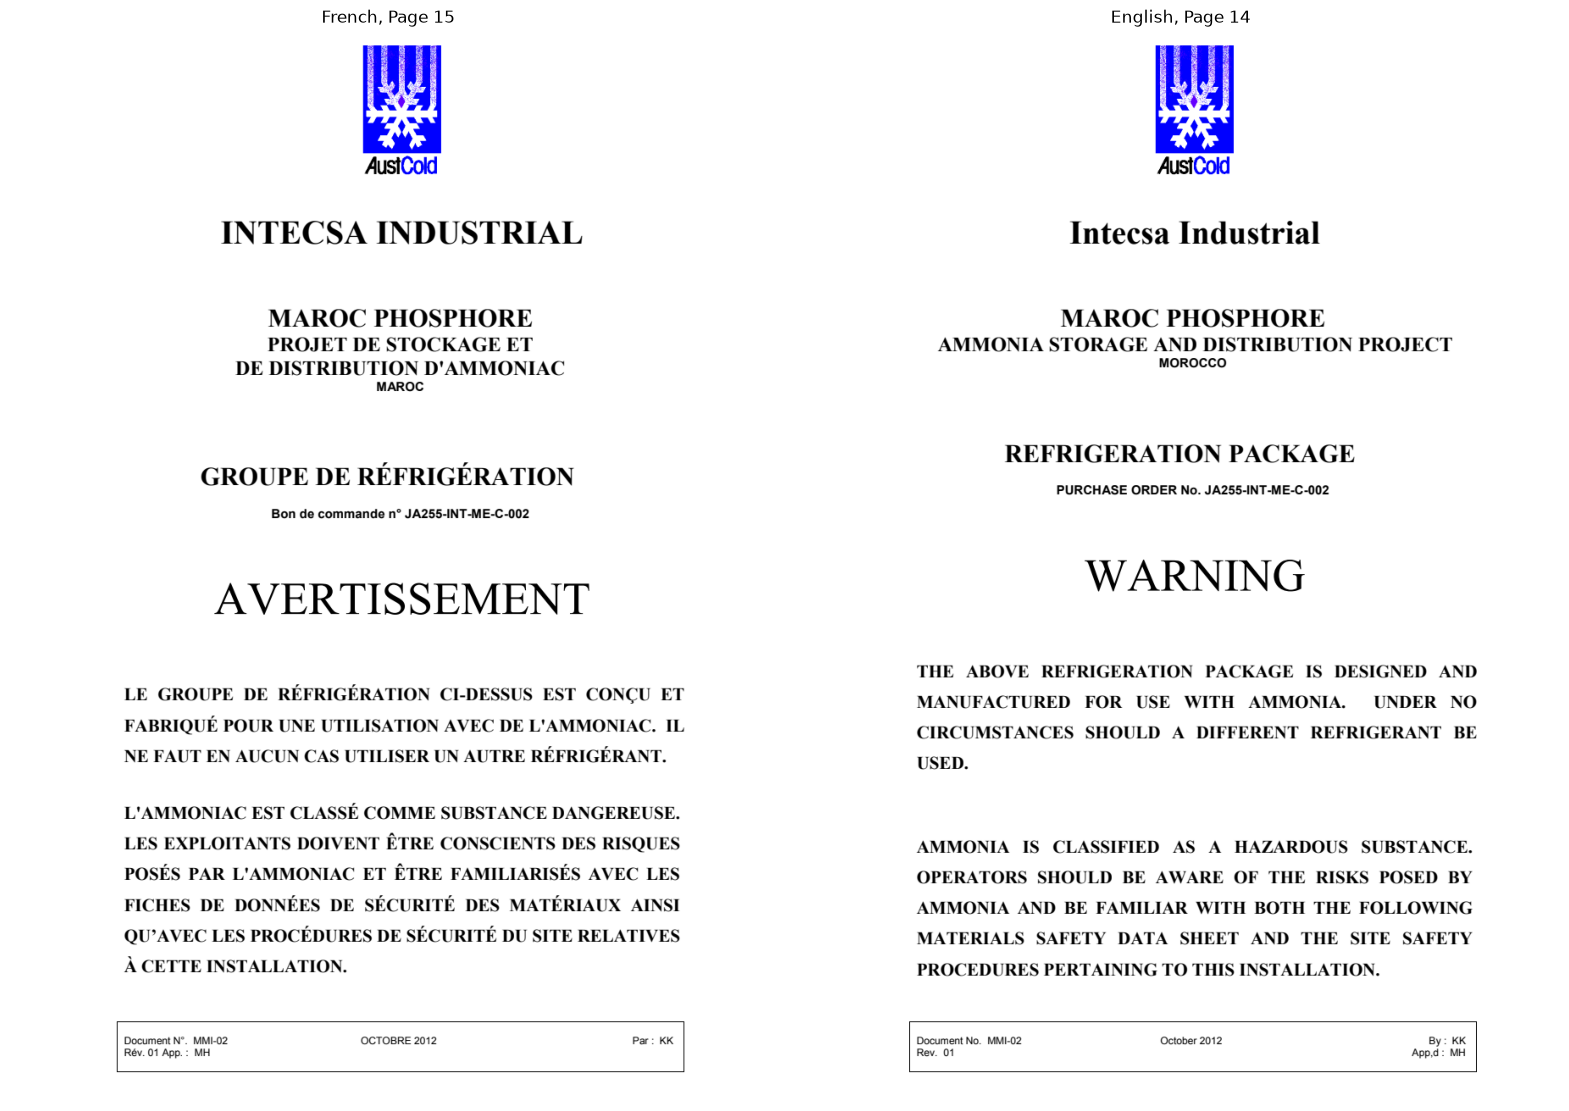

True

In [23]:
import matplotlib.pyplot as plt

doc = pdfium.PdfDocument(str(PDF_AUSTCOLD))

FRENCH_PAGE = 15
ENGLISH_PAGE = 14

fig, axes = plt.subplots(1, 2, figsize=(16, 11))

for ax, page_num, label in zip(
    axes,
    [FRENCH_PAGE, ENGLISH_PAGE],
    ["French", "English"]
):
    page = doc[page_num - 1]
    image = page.render(scale=1.5).to_pil()

    ax.imshow(image)
    ax.set_title(f"{label}, Page {page_num}")
    ax.axis("off")

plt.tight_layout()
plt.show()

doc.close()

## PDFs Structure Inspection

### AUSTCOLD PDF Inspection

**Document Structure:**

The document groups several categories of documents:

1. General information / safety / history
2. Control description and philosophy
3. Technical data
4. Maintenance data
5. Equipment manuals
6. Instrumentation manuals
7. Valve documentation
8. As Built Drawings

- The PDF is organized into **sections**, with Section 3 (Technical Data) being the main source for equipment specifications.
- Section 3 contains dedicated data sheets for compressors, motors, pumps, condensers, valves, instrumentation, etc. :contentReference[oaicite:0]{index=0}
- Other sections provide useful supporting information:
  - **Section 5:** equipment manufacturer manuals, useful for confirmation and images.
  - **Section 6–7:** instrumentation and valves.
  - **Section 8:** drawings and graphical information. :contentReference[oaicite:1]{index=1} :contentReference[oaicite:2]{index=2} :contentReference[oaicite:3]{index=3}
- The PDF contains different page/document types, so **one extraction method should not be applied to every page**. :contentReference[oaicite:4]{index=4}
- The initial equipment list can be obtained from the index and used as a **starting taxonomy**, not as a complete equipment inventory. :contentReference[oaicite:5]{index=5}
- Extraction should be separated from **classification**: first extract what is explicitly present in the PDF, then map it to the application's categories. :contentReference[oaicite:6]{index=6}

Inspection of the `AUSTCOLD PDF` shows that the document is organized primarily by **section identifiers** rather than conventional page numbers.

The summary/index lists sections such as `1.01`, `1.02`, `3.01`, `3.02`, etc., but does not provide corresponding PDF page numbers. Inside the document, each section begins with a dedicated page displaying its section number, followed by the related content.

This structure means that **section identifiers are more useful for navigating and organizing the extracted information than PDF page numbers**.

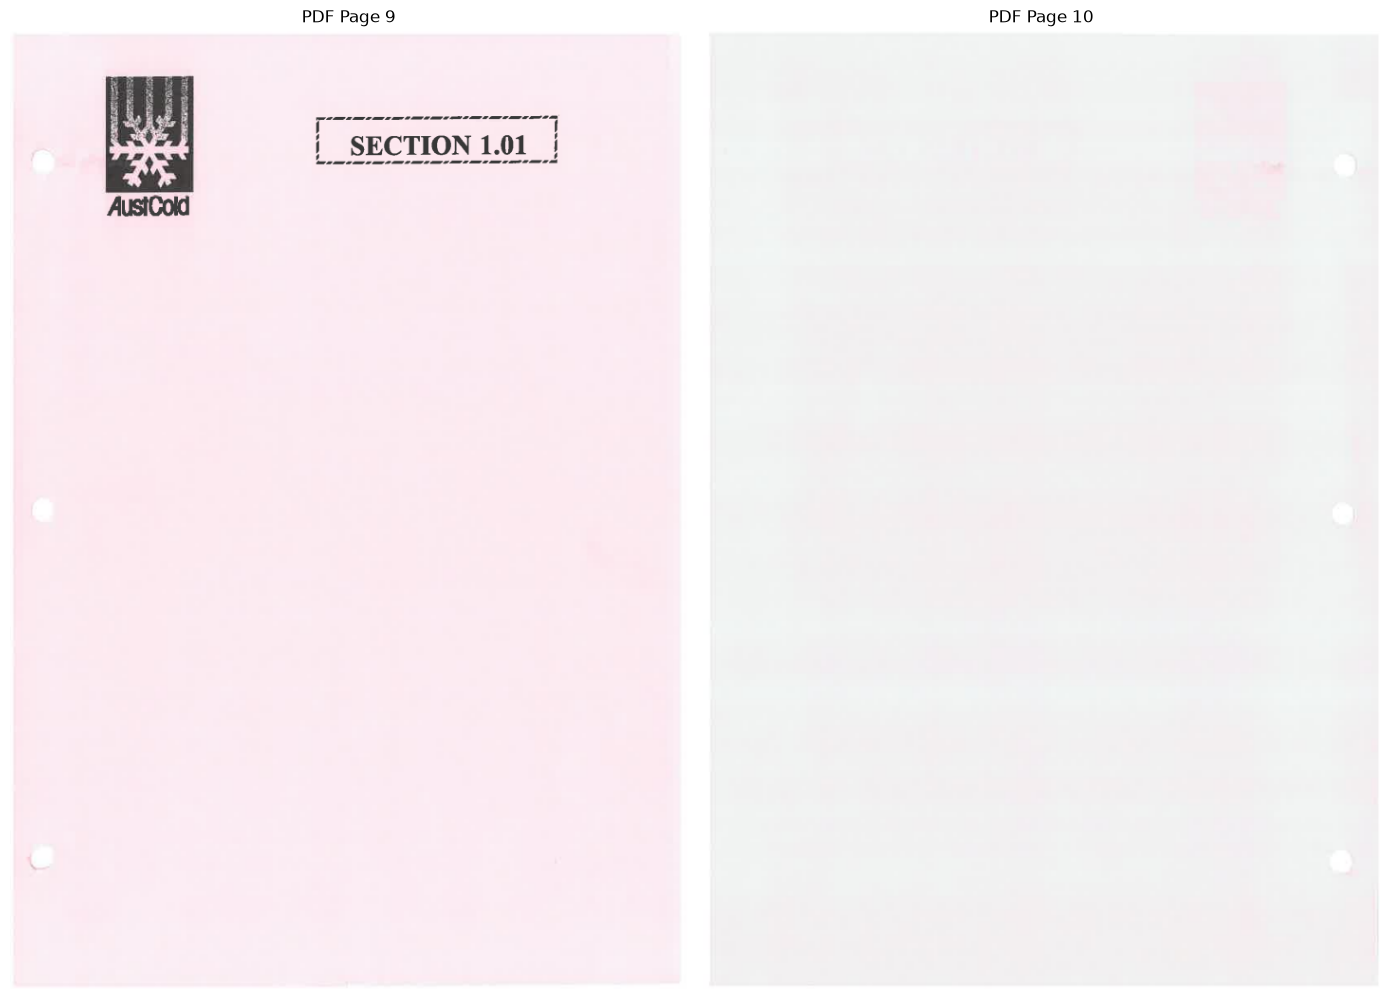

True

In [25]:
import matplotlib.pyplot as plt

doc = pdfium.PdfDocument(str(PDF_AUSTCOLD))

# Pages to inspect
pages_to_show = [9, 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

for ax, page_num in zip(axes, pages_to_show):
    page = doc[page_num - 1]
    image = page.render(scale=1.2).to_pil()

    ax.imshow(image)
    ax.set_title(f"PDF Page {page_num}")
    ax.axis("off")

plt.tight_layout()
plt.show()

doc.close()

**Implication for extraction:**

Since most of the section pages are **scanned/image-based** rather than native-text PDF pages. As a result, direct text extraction will not capture all of the document content.

The **section identifier should be used as the main structural anchor**, while OCR should be applied to scanned pages when their content needs to be extracted.

### MYCOM PDF Inspection

The source PDF is a large Operating and Maintenance Manual

Unlike a simple equipment datasheet, the document is composed of multiple technical document categories.

The beginning of the manual contains a structured summary/table of contents that provides an overview of the technical documentation included in the manual.

In [ ]:
import pandas as pd

mycom_name = next(
    name for name, path in PDFS.items()
    if Path(path) == Path(PDF_MYCOM)
)

mycom_tables = all_tables[mycom_name]

all_rows = []

for t in mycom_tables:
    if t['page'] in [5, 6]:
        rows = t['all_rows']

        # Skip the header of every table after the first one
        if not all_rows:
            all_rows.extend(rows)
        else:
            all_rows.extend(rows[1:])


In [42]:
def clean_pdf_text(x):
    if pd.isna(x):
        return ""

    x = str(x)

    # Remove PDF encoding artifacts
    x = re.sub(r'\(cid:\d+\)', ' ', x)

    # Clean whitespace
    x = x.replace('\n', ' ')
    x = x.replace('\xa0', ' ')
    x = re.sub(r'\s+', ' ', x).strip()

    return x


# Create DataFrame
toc_df = pd.DataFrame(
    all_rows,
    columns=['Item', 'Description', 'Doc. No.']
)

# Clean cells
toc_df = toc_df.map(clean_pdf_text)

# Remove completely empty rows
toc_df = toc_df[
    toc_df[['Item', 'Description', 'Doc. No.']]
    .ne('')
    .any(axis=1)
].reset_index(drop=True)

display(toc_df)

,Item,Description,Doc. No.
0,,Description,Doc. No.
1,1.,GENERAL DOCUMENTS,
2,1.1,DOCUMENTS & DRAWINGS LIST,P1-REF-LST-12-123-007
3,1.2,SUBVENDOR LIST,P1-REF-LST-12-123-003
4,1.3,NOISE DATA SHEET,P1-REF-DSS-12-123-008
...,...,...,...
66,7.7,CAUSE & EFFECTS CHART,P1-REF-LST-12-123-011
67,7.8,PACKAGE I/O LIST,P1-REF-LST-12-123-006
68,7.9,CABLES LIST,P1-REF-LST-12-123-004
69,7.10,LOCAL GAUGE BOARD & JB LAY OUT,P1-REF-2012-123-018


The table of contents can be used to identify documents that are likely to
contain information relevant to equipment asset creation.

Candidate document types include:

- data sheets;
- equipment specifications;
- equipment identification documents;
- mechanical drawings;
- assembly drawings;
- electrical data sheets;
- performance documentation.

Other documents may be less directly relevant to asset creation, for example:

- general project documentation;
- painting specifications;
- testing procedures;
- unrelated package documentation.

This does not mean that these documents should automatically be discarded.
The purpose of this step is to prioritize documents for further inspection.

---
*Notebook: `01_pdf_exploration.ipynb`  
Project: Industrial Equipment Data Extraction*